# Differential Privacy

- K-anonymity and l-diversity techniques protect records by grouping them. Differential privacy protects individuals by adding mathematical noise to query results. 
- The guarantee: whether or not any single person's record is in the dataset, the query output looks essentially the same.
- The key parameters:
    - Epsilon (ε) privacy budget.
 
          -> Lower = more privacy, more noise, less accuracy.
          -> Higher = less privacy, less noise, more accuracy.
 
    - Sensitivity (Δf) — how much one person's record can change the query result. For average salary, sensitivity = (max_salary - min_salary) / n
 
      
    - Laplace mechanism, add noise drawn from Laplace distribution scaled to sensitivity/epsilon

In [3]:
# differential_privacy.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('hr_dataset.csv')

In [4]:
# ── Core Laplace Mechanism ──────────────────────────────────────────
def laplace_mechanism(true_value, sensitivity, epsilon):
    """
    Add Laplace noise to a true value.
    noise scale = sensitivity / epsilon
    Lower epsilon = more noise = more privacy
    """
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return true_value + noise

def compute_sensitivity(df, column):
    """
    Global sensitivity for average query:
    max change one record can cause = (max - min) / n
    """
    return (df[column].max() - df[column].min()) / len(df)


In [5]:
# ── Private Average Salary by Department ───────────────────────────
def private_avg_salary(df, epsilon):
    """
    Compute differentially private average salary per department.
    Each department query uses a portion of the epsilon budget.
    """
    sensitivity = compute_sensitivity(df, 'salary')
    results = []
    
    for dept in df['department'].unique():
        dept_df = df[df['department'] == dept]
        true_avg = dept_df['salary'].mean()
        private_avg = laplace_mechanism(true_avg, sensitivity, epsilon)
        results.append({
            'department': dept,
            'true_avg_salary': round(true_avg, 2),
            'private_avg_salary': round(private_avg, 2),
            'noise_added': round(private_avg - true_avg, 2),
            'epsilon': epsilon
        })
    
    return pd.DataFrame(results)


In [6]:
# ── Run across epsilon values ───────────────────────────────────────
epsilons = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
results = []

for eps in epsilons:
    result = private_avg_salary(df, eps)
    results.append(result)
    
all_results = pd.concat(results, ignore_index=True)


In [7]:
# ── Accuracy metric: Mean Absolute Error per epsilon ───────────────
print("Privacy/Accuracy Tradeoff:")
print(f"{'Epsilon':<12} {'Avg Noise |$|':<20} {'Max Noise |$|':<20}")
print("-" * 52)

for eps in epsilons:
    eps_df = all_results[all_results['epsilon'] == eps]
    avg_noise = eps_df['noise_added'].abs().mean()
    max_noise = eps_df['noise_added'].abs().max()
    print(f"{eps:<12} ${avg_noise:<19,.0f} ${max_noise:<19,.0f}")

Privacy/Accuracy Tradeoff:
Epsilon      Avg Noise |$|        Max Noise |$|       
----------------------------------------------------
0.01         $1,819               $2,512              
0.1          $333                 $862                
0.5          $84                  $201                
1.0          $37                  $120                
5.0          $12                  $26                 
10.0         $1                   $2                  


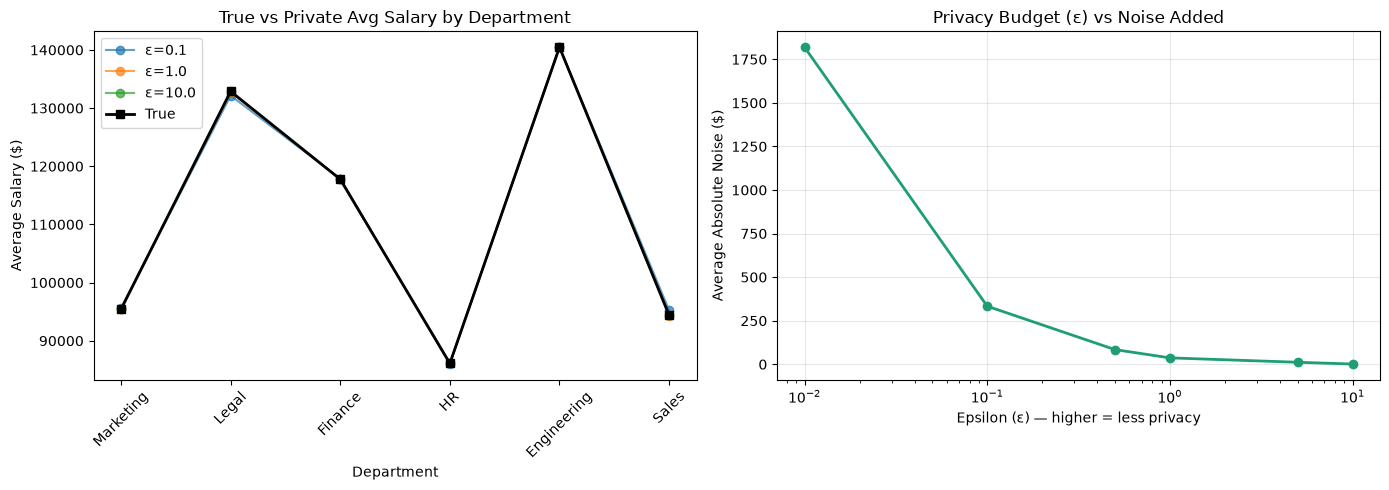


Sensitivity: 24.83
Chart saved as dp_tradeoff.png


In [8]:
# ── Visualize tradeoff ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True vs Private salary by department at different epsilons
for eps in [0.1, 1.0, 10.0]:
    eps_df = all_results[all_results['epsilon'] == eps]
    axes[0].plot(
        eps_df['department'], 
        eps_df['private_avg_salary'],
        marker='o', label=f'ε={eps}', alpha=0.7
    )

true_avgs = all_results[all_results['epsilon'] == epsilons[0]][
    ['department', 'true_avg_salary']
].drop_duplicates()
axes[0].plot(
    true_avgs['department'],
    true_avgs['true_avg_salary'],
    marker='s', label='True', linewidth=2, color='black'
)
axes[0].set_title('True vs Private Avg Salary by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Average Salary ($)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Average absolute noise vs epsilon
noise_by_eps = all_results.groupby('epsilon')['noise_added'].apply(
    lambda x: x.abs().mean()
).reset_index()
axes[1].plot(
    noise_by_eps['epsilon'], 
    noise_by_eps['noise_added'],
    marker='o', color='#1D9E75', linewidth=2
)
axes[1].set_title('Privacy Budget (ε) vs Noise Added')
axes[1].set_xlabel('Epsilon (ε) — higher = less privacy')
axes[1].set_ylabel('Average Absolute Noise ($)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dp_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSensitivity:", round(compute_sensitivity(df, 'salary'), 2))
print("Chart saved as dp_tradeoff.png")


# Observations
- <b>Results on the left graph:</b> the ε=0.1, ε=1.0, and ε=10.0 lines are all overlapping with the True (black) line almost perfectly. This tells we the sensitivity is very low (24.83), meaning even at ε=0.1 the noise scale is only 24.83/0.1 = 248 dollars average noise to salary averages, which is tiny relative to salaries in the 80K-180K range.

- Diferrential privacy becomes more accurate as n grows, becuase any single record has less influence on aggregate queries. In small datasets (n ~= 50) sensitivity would be 100x higher (2,483 dollars) making $$ \varepsilon=0.1 $$ essentially unusable.

- Our Laplace mechanism most likely working correctly, the data just happens to have low sensitivity because we have 5,000 records (sensitivity = salary_range / n).

- <b>Results on the right graph: </b> The curve is exactly what differential privacy theory predicts, exponential decay as ε increases. The steep drop from ε=0.01 ($1,800 noise) to ε=0.1 ($325 noise) is dramatic, then it flattens. This is the classic privacy/utility tradeoff curve. Our visualization captures it perfectly.


# Composition

Every query we run consumes epsilon. If we run 10 department queries, each with ε=1.0, our total privacy loss is ε=10.0. Meaning epsilon is budget, not a parameter.

We'd need to allocate epsilon carefully across all the queries our system needs to answer. This is why production differential privacy systems have a privacy accountant.

At ε=0.01 --> extreme privacy, noise likely larger than actual salary differences between departments. Queries are essentially useless.

At ε=0.1 --> strong privacy, noisy but directionally correct.

At ε=1.0 --> standard choice in many real systems, reasonable accuracy.

At ε=10.0 --> weak privacy guarantee, very close to true values.

Real-world examples: 

- Google's RAPPOR system uses ε=1.0 
per query.

- Apple's differential privacy implementation uses 
ε values between 2.0-8.0 depending on the data type. 

- LinkedIn's salary insights feature (which this project 
directly models) uses differential privacy with carefully 
allocated epsilon budgets across their aggregate reporting 
queries.

Sensitivity = (max_salary - min_salary) / n 
            = ($124,000 range) / 5000 
            = $24.83

With 5,000 records, sensitivity is very low meaning even 
strong privacy (ε=0.1) adds only ~$248 average noise to 
salary averages. This is a property of large datasets: 
differential privacy becomes more accurate as n grows, 
because any single record has less influence on aggregate 
queries. In a small dataset (n=50), sensitivity would be 
100x higher ($2,483) making ε=0.1 essentially unusable.

# Sensitivity is query dependent, not just dataset dependent

In [13]:
""" A private headcount query alongside the salary query.
    It demonstrates that DP applies to count queries too, and headcount has different sensitivity
    (sensitivity=1 for counts, regardless of dataset size):"""
def private_headcount(df, epsilon):
    """
    Count query sensitivity = 1 (one record changes count by at most 1)
    Much lower sensitivity than salary average
    """
    results = []
    for dept in df['department'].unique():
        true_count = len(df[df['department'] == dept])
        # sensitivity=1 for counting queries
        private_count = laplace_mechanism(true_count, 1, epsilon)
        private_count = max(0, round(private_count))  # counts can't be negative
        results.append({
            'department': dept,
            'true_count': true_count,
            'private_count': private_count,
            'epsilon': epsilon
        })
    return pd.DataFrame(results)

# Compare salary sensitivity vs count sensitivity
print(f"Salary query sensitivity: {compute_sensitivity(df, 'salary'):.2f}")
print(f"Count query sensitivity: 1.0 (always)")
print(f"\nThis means count queries are inherently more privacy friendly")
print(f"than salary queries at the same epsilon value")



Salary query sensitivity: 24.83
Count query sensitivity: 1.0 (always)

This means count queries are inherently more privacy friendly
than salary queries at the same epsilon value


# Results

<b>Key insight:</b> Sensitivity is query dependent, not just dataset dependent.

A count query ("how many employees in Engineering?") has sensitivity=1 
because adding or removing one person changes the count by exactly 1.
A salary average query has sensitivity=salary_range/n because one 
person's extreme salary can shift the average by that amount.

<b>Practical implication:</b> At ε=1.0, a count query adds Laplace(0, 1) 
noise, typically less than 3 people off. A salary query adds 
Laplace(0, 24.83) noise, typically less than $75 off at this 
dataset size. Both are acceptable for aggregate reporting, but 
the epsilon budget allocation should reflect these different 
sensitivities.

Production systems like LinkedIn's salary insights or Google's 
RAPPOR allocate epsilon per query type based on sensitivity, 
high sensitivity queries get smaller epsilon allocations 
(more noise) to stay within the total privacy budget.
